In [1]:
from utils.utils import DataLoader, DopplerDataset, plot_learning_curves
from networks.model import Network_Class
import numpy as np
import matplotlib.pyplot as plt
import yaml
import os

# Load Data
base_path = "/Volumes/HIP_BACKUP/MEMOIRE/Code/MyDB2"
all = [f"NewExp{i}" for i in range(1, 51)]


🔄 Chargement des données: 100%|██████████| 50/50 [00:01<00:00, 33.17exp/s]


🔔 Starting Regression/BET_ResNet4
✅ Network Initialized


Testing (regression): 100%|██████████| 310/310 [02:07<00:00,  2.43batch/s, mse=0.0106]


📏 Test MSE (moyenne par échantillon): 0.0173
📏 Test MSE (denormalized): 0.6472


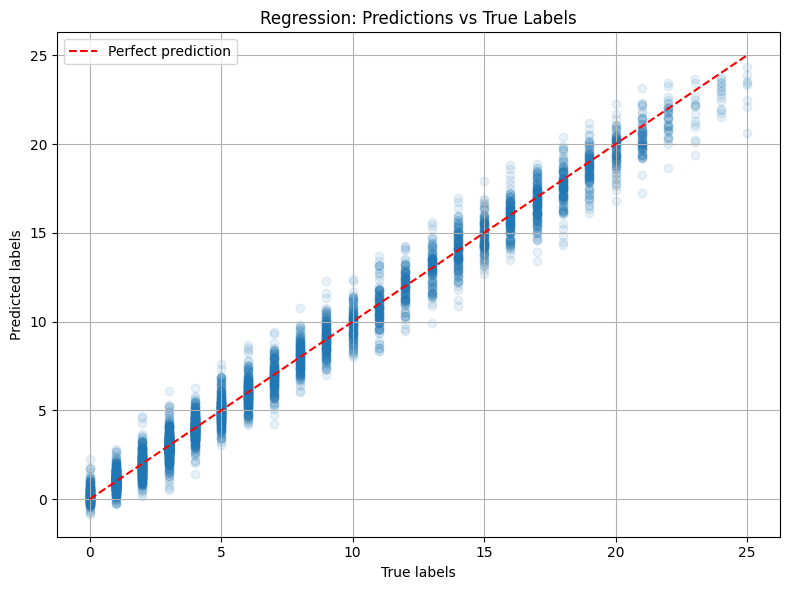

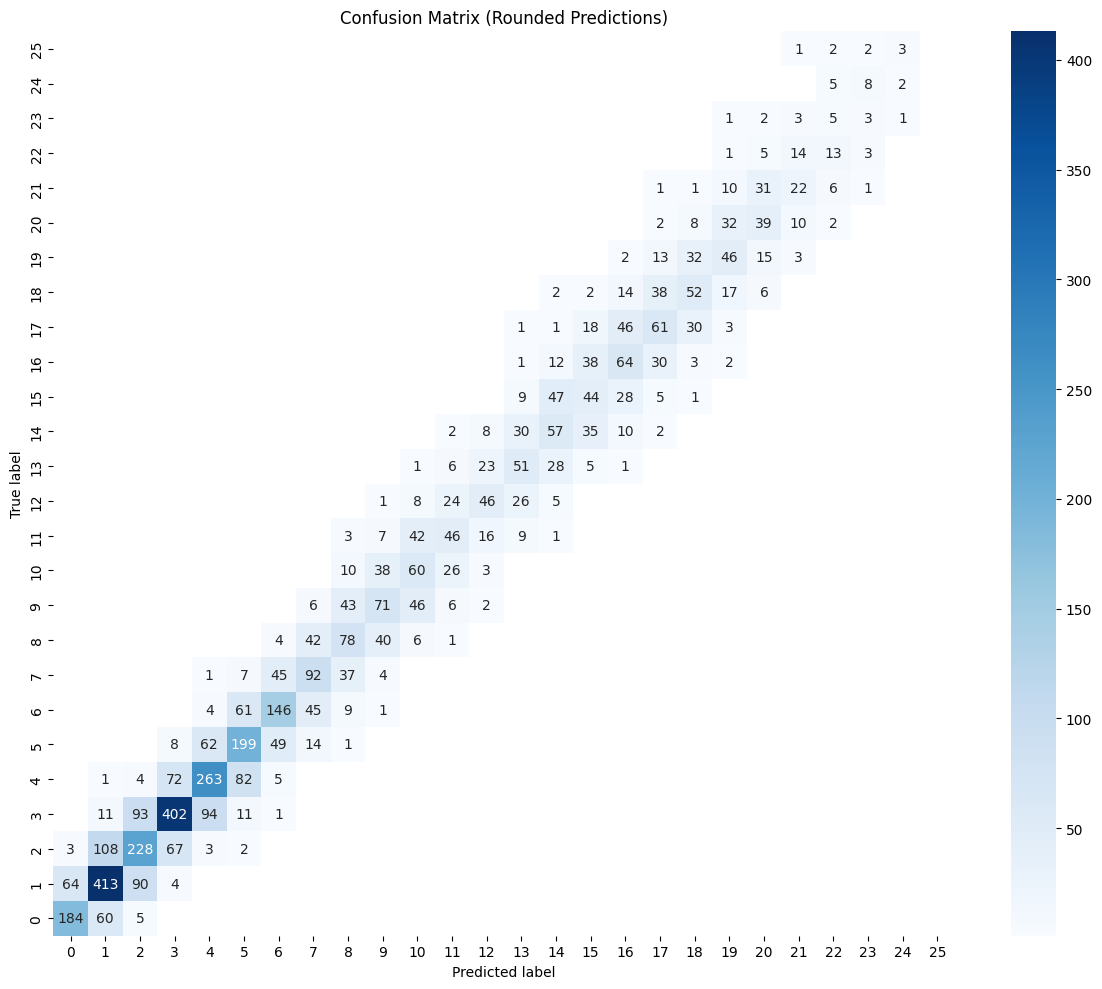

In [4]:
l_exp = [f"Regression/BET_ResNet4"]

data_loader = DataLoader(base_path, exp_list=all)

for exp in l_exp :
    #exp = "DefaultExp"
    print(f"🔔 Starting {exp}")
    stream = open(f"exp_list/{exp}.yaml", 'r')
    param  = yaml.safe_load(stream)
    param["TRAINING"]["DEVICE"] = 'mps'

    resultsPath = os.path.join("results", exp)

    # Create the directory
    if not os.path.exists(resultsPath):
        os.makedirs(resultsPath)

    myNetwork = Network_Class(data_loader, param, resultsPath, sub_sample_factor=1)

    # Train the network
    #train_losses, val_losses =  myNetwork.train()

    # Test the network
    myNetwork.loadWeight()
    myNetwork.test()   





In [4]:
print(len(myNetwork.dataSetTrain))
print(len(myNetwork.dataSetTest))
print(len(myNetwork.dataSetVal))

39640
4955
4955


In [ ]:
num_params = sum(p.numel() for p in myNetwork.model.parameters())
print(f"Number of parameters: {num_params}") 
# V1 = 2.147.874.498
# V2 = 8.482.754
# V3 = 2.190.530
# V_reg = 2.190.465
# V_reg_48CH = 12.833.441
# V_reg4 = 8.505.697
# V_reg5 = 3.201.769
# Res Net = 11.175.554

Number of parameters: 11175554


[0.21260171 0.11195632 0.08037161 0.06134718 0.04653862 0.03665729
 0.03145919 0.02598988 0.02185484 0.01971191 0.01768396 0.01569957
 0.01435691 0.0135905  0.01198103 0.01099491 0.01027351 0.00965628
 0.00913459 0.00887553 0.00812187 0.00785247 0.00713297 0.00720191
 0.0068751  0.00612171 0.00602396 0.00561827 0.00519439 0.00528199
 0.00519732 0.00469556 0.00455473 0.00450357 0.00427744 0.00405288
 0.00399172 0.00386294 0.00376177 0.00363642]
[0.19316119 0.19490583 0.09205886 0.12103602 0.05837821 0.03880653
 0.08965572 0.03538046 0.04637287 0.03522225 0.03296536 0.04024475
 0.1088094  0.03381085 0.02379503 0.03657811 0.0231946  0.03090282
 0.03680245 0.02792396 0.0221444  0.02152643 0.0290467  0.02165938
 0.02197183 0.0205069  0.02504284 0.01920729 0.02993258 0.02031919
 0.01966998 0.01928284 0.01949353 0.01870677 0.02653766 0.01856266
 0.01883343 0.01698403 0.02438704 0.01831783]


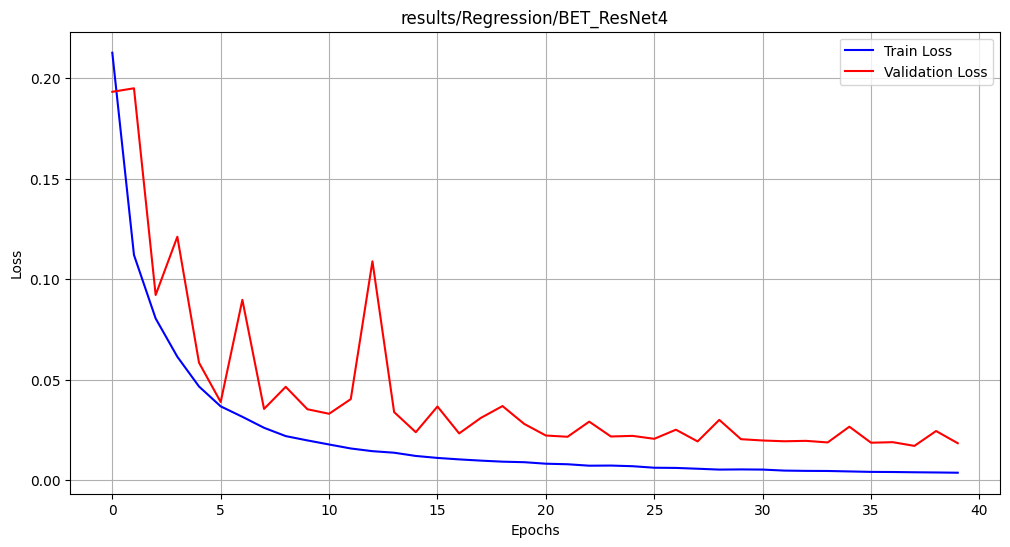

In [5]:
# Load learning curves
train_losses = np.load(os.path.join(resultsPath, "train_losses.npy"))
val_losses = np.load(os.path.join(resultsPath, "val_losses.npy"))
print(train_losses)
print(val_losses)
plot_learning_curves(train_losses, val_losses, resultsPath)